In [1]:
import pandas as pd

# Load both datasets
fake_df = pd.read_csv("../data/Fake.csv")
true_df = pd.read_csv("../data/True.csv")

# Add labels
fake_df["label"] = "FAKE"
true_df["label"] = "REAL"

# Combine into one dataset
df = pd.concat([fake_df, true_df], ignore_index=True)

print("✅ Data loaded successfully!")
print(f"Total articles: {len(df)}")
print(f"Fake articles: {len(fake_df)}")
print(f"Real articles: {len(true_df)}")

ModuleNotFoundError: No module named 'pandas'

In [1]:
import pandas as pd

fake_df = pd.read_csv("../data/Fake.csv")
true_df = pd.read_csv("../data/True.csv")

fake_df["label"] = "FAKE"
true_df["label"] = "REAL"

df = pd.concat([fake_df, true_df], ignore_index=True)

print("✅ Data loaded successfully!")
print(f"Total articles: {len(df)}")
print(f"Fake articles: {len(fake_df)}")
print(f"Real articles: {len(true_df)}")

✅ Data loaded successfully!
Total articles: 44898
Fake articles: 23481
Real articles: 21417


In [2]:
# Look at first 5 rows
print("First 5 rows of our dataset:")
print(df.head())

print("\nColumns in our dataset:")
print(df.columns.tolist())

print("\nShape of dataset (rows, columns):")
print(df.shape)

First 5 rows of our dataset:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date label  
0  December 31, 2017  FAKE  
1  December 31, 2017  FAKE  
2  December 30, 2017  FAKE  
3  December 29, 2017  FAKE  
4  December 25, 2017  FAKE  

Columns in our dataset:
['title', 'text', 'subject', 'date', 'label']

Sha

In [3]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values in each column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Data types:
title      str
text       str
subject    str
date       str
label      str
dtype: object


In [4]:
print("📊 DATASET STATISTICS")
print("=" * 40)
print(f"Total articles: {len(df)}")
print(f"Fake articles: {len(df[df['label'] == 'FAKE'])}")
print(f"Real articles: {len(df[df['label'] == 'REAL'])}")
print(f"Total columns: {len(df.columns)}")

print("\n📰 Sample FAKE headline:")
print(df[df['label'] == 'FAKE']['title'].iloc[0])

print("\n📰 Sample REAL headline:")
print(df[df['label'] == 'REAL']['title'].iloc[0])

📊 DATASET STATISTICS
Total articles: 44898
Fake articles: 23481
Real articles: 21417
Total columns: 5

📰 Sample FAKE headline:
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing

📰 Sample REAL headline:
As U.S. budget fight looms, Republicans flip their fiscal script


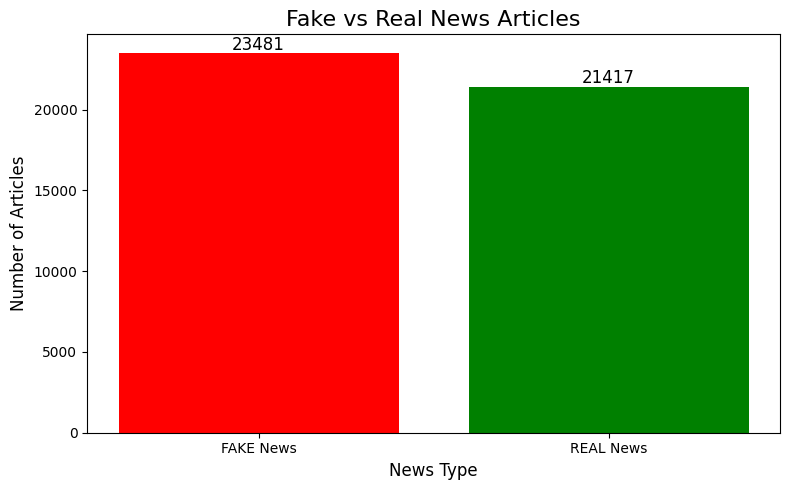

✅ Chart saved!


In [5]:
import matplotlib.pyplot as plt

# Count fake vs real
counts = df['label'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(['FAKE News', 'REAL News'], 
        counts.values, 
        color=['red', 'green'])

plt.title('Fake vs Real News Articles', fontsize=16)
plt.xlabel('News Type', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)

for i, count in enumerate(counts.values):
    plt.text(i, count + 200, str(count), 
             ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('../data/fake_vs_real.png')
plt.show()

print("✅ Chart saved!")

In [6]:
# Add text length column
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['title_length'] = df['title'].apply(len)

# Compare fake vs real
print("📊 FAKE NEWS Statistics:")
fake_stats = df[df['label'] == 'FAKE'][['text_length', 'word_count']].mean()
print(f"  Average text length: {fake_stats['text_length']:.0f} characters")
print(f"  Average word count: {fake_stats['word_count']:.0f} words")

print("\n📊 REAL NEWS Statistics:")
real_stats = df[df['label'] == 'REAL'][['text_length', 'word_count']].mean()
print(f"  Average text length: {real_stats['text_length']:.0f} characters")
print(f"  Average word count: {real_stats['word_count']:.0f} words")

📊 FAKE NEWS Statistics:
  Average text length: 2547 characters
  Average word count: 423 words

📊 REAL NEWS Statistics:
  Average text length: 2383 characters
  Average word count: 386 words


In [7]:

from collections import Counter

# Get all fake news text
fake_text = " ".join(df[df['label'] == 'FAKE']['title'].tolist())
real_text = " ".join(df[df['label'] == 'REAL']['title'].tolist())

# Count words
fake_words = Counter(fake_text.lower().split()).most_common(10)
real_words = Counter(real_text.lower().split()).most_common(10)

print("🔴 TOP 10 words in FAKE news titles:")
for word, count in fake_words:
    print(f"  '{word}' appears {count} times")

print("\n🟢 TOP 10 words in REAL news titles:")
for word, count in real_words:
    print(f"  '{word}' appears {count} times")

🔴 TOP 10 words in FAKE news titles:
  'to' appears 9443 times
  'trump' appears 6615 times
  'the' appears 5978 times
  'of' appears 5141 times
  '[video]' appears 5054 times
  'for' appears 4793 times
  'in' appears 4493 times
  'on' appears 3594 times
  'and' appears 3482 times
  'a' appears 3479 times

🟢 TOP 10 words in REAL news titles:
  'to' appears 7798 times
  'in' appears 4591 times
  'trump' appears 4401 times
  'u.s.' appears 3872 times
  'on' appears 3333 times
  'of' appears 3009 times
  'says' appears 2970 times
  'for' appears 2770 times
  'with' appears 1496 times
  'house' appears 1383 times


In [8]:
# Save the combined dataset for later use
df.to_csv('../data/news_dataset.csv', index=False)

print("✅ Dataset saved to data/news_dataset.csv")
print(f"Total articles saved: {len(df)}")
print("\n🎉 Phase 2 Data Exploration COMPLETE!")
print("We are ready to build our AI model!")

✅ Dataset saved to data/news_dataset.csv
Total articles saved: 44898

🎉 Phase 2 Data Exploration COMPLETE!
We are ready to build our AI model!
